<a href="https://www.kaggle.com/code/asishjosekakkadan/house-price-timeseries?scriptVersionId=272638675" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Forecasting House property sales prices

This project focuses on forecasting house property sales prices over time using a time series forecasting approach.
The primary objective is to analyze the price trends of residential properties and predict future sales prices based on historical data.

To achieve this, multiple forecasting techniques — both statistical and machine learning-based — were implemented and compared to identify the most effective model for price prediction.

The models evaluated include:

ARIMA (AutoRegressive Integrated Moving Average)

SARIMA (Seasonal ARIMA)

Holt-Winters (Exponential Smoothing)

Prophet (Facebook’s time series model)

LSTM (Long Short-Term Memory Neural Network)

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Dataset Description

The dataset used in this project contains information about house property sales from 2007 to 2019 for a specific region.

- Feature	Description
- saledate	Date of property sale (used as the time index for forecasting).
- price	Sale price of the property (target variable).
- type	Type of property — either House or Unit.
- bedrooms	Number of bedrooms (ranging from 1 to 5).
- postcode	Location identifier representing the sale area.
- MA	Moving average feature computed over price, used in some models for trend smoothing.

The data was resampled monthly to create a consistent time series.

In [2]:
data = pd.read_csv('/kaggle/input/property-sales/raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [3]:
data.shape

(29580, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datesold      29580 non-null  object
 1   postcode      29580 non-null  int64 
 2   price         29580 non-null  int64 
 3   propertyType  29580 non-null  object
 4   bedrooms      29580 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [5]:
data['propertyType'].unique()

array(['house', 'unit'], dtype=object)

In [6]:
data['propertyType'].value_counts()

propertyType
house    24552
unit      5028
Name: count, dtype: int64

In [7]:
data = data.rename(columns={'propertyType':'type',
                           'datesold':'date',
                           })

In [8]:
data['date'] = pd.to_datetime(data['date'])

In [9]:
data['postcode'].unique()

array([2607, 2906, 2905, 2606, 2902, 2612, 2904, 2615, 2914, 2602, 2600,
       2605, 2603, 2611, 2903, 2617, 2913, 2604, 2614, 2912, 2601, 2900,
       2620, 2618, 2616, 2911, 2609])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[ns]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  object        
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


| Feature    | Type        | Example Values | Importance  | Role in Forecasting         |
| ---------- | ----------- | -------------- | ----------- | --------------------------- |
| `date` | Datetime    | 2015-06-23     | High        | Time index                  |
| `price`    | Numeric     | 450000         | Target      | Forecast variable           |
| `type`     | Categorical | house/unit     | Medium–High | Optional regressor          |
| `bedrooms` | Ordinal     | 1–5            | Medium      | Optional regressor          |
| `postcode` | Categorical | 3000, 3001...  | High        | Optional regressor / filter |


# Univariate House Price Forecast

## Preprocessing

In [11]:
df = data[['date', 'price']].set_index('date')
df.head()

,price
date,
2007-02-07,525000
2007-02-27,290000
2007-03-07,328000
2007-03-09,380000
2007-03-21,310000


In [12]:
# resampling

daily_df = df.resample('D').mean()
monthly_df = df.resample('ME').mean()

#### Train  Test Split

In [13]:
split_ratio = 0.8
split_index = int(len(monthly_df) * split_ratio)

train = monthly_df.iloc[:split_index]
test = monthly_df.iloc[split_index:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train end date:", train.index[-1])
print("Test start date:", test.index[0])

Train shape: (120, 1)
Test shape: (30, 1)
Train end date: 2017-01-31 00:00:00
Test start date: 2017-02-28 00:00:00


#### plots

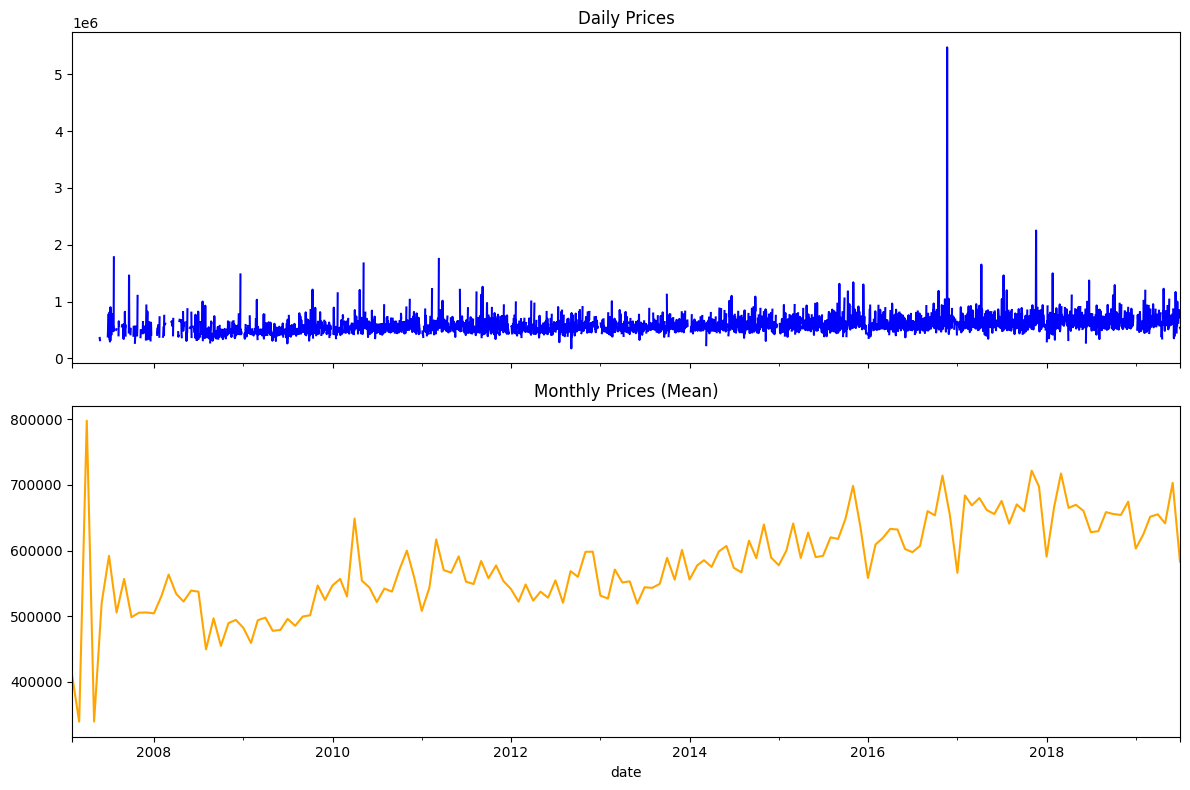

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

daily_df['price'].plot(ax=ax[0], title='Daily Prices', color='blue')
monthly_df['price'].plot(ax=ax[1], title='Monthly Prices (Mean)', color='orange')

plt.tight_layout()
plt.show()

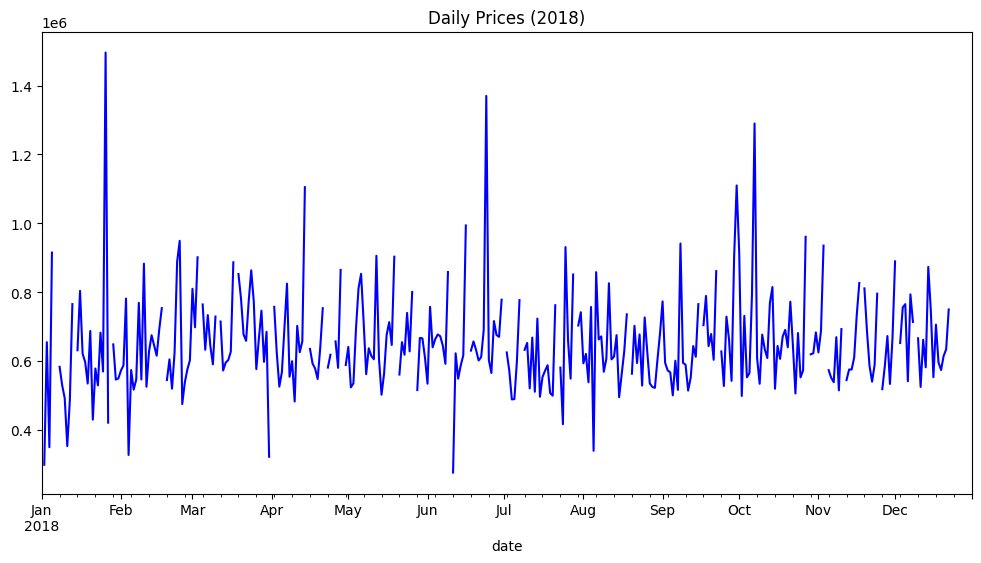

In [15]:

# Filter one-year data (example: 2018)
daily_one_year = daily_df.loc['2018']
plt.figure(figsize=(12,6))
daily_one_year['price'].plot(title='Daily Prices (2018)', color='blue')

plt.show()


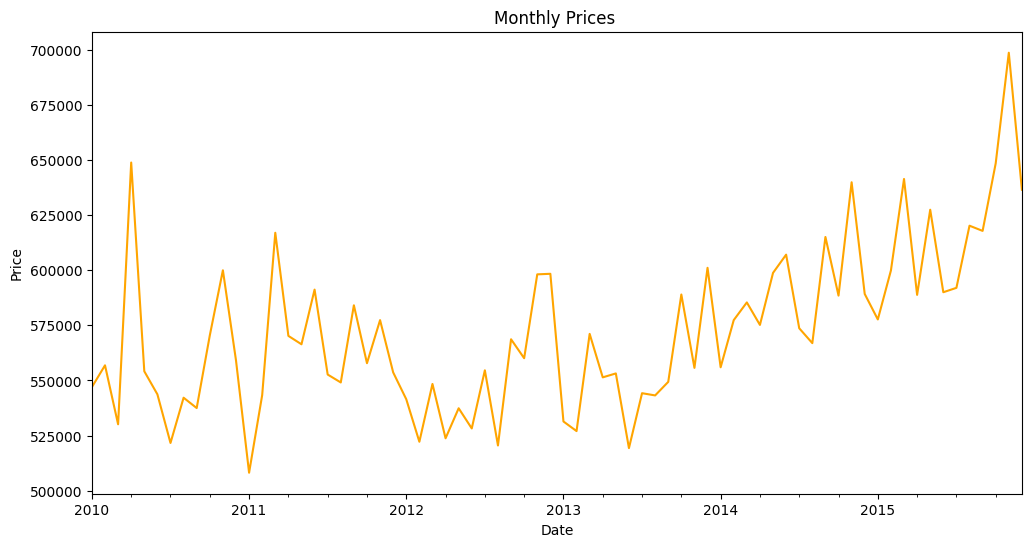

In [16]:
monthly = monthly_df.loc['2010':'2015']   
plt.figure(figsize=(12,6))
monthly['price'].plot(title='Monthly Prices ', color='orange')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

The data shows a clear long-term upward trend with mild annual seasonality and occasional volatility.

In [17]:
#daily_df = daily_df['price'].interpolate(method='linear')
#monthly_df = monthly_df['price'].interpolate(method='linear')

#### Seasonal Decompose

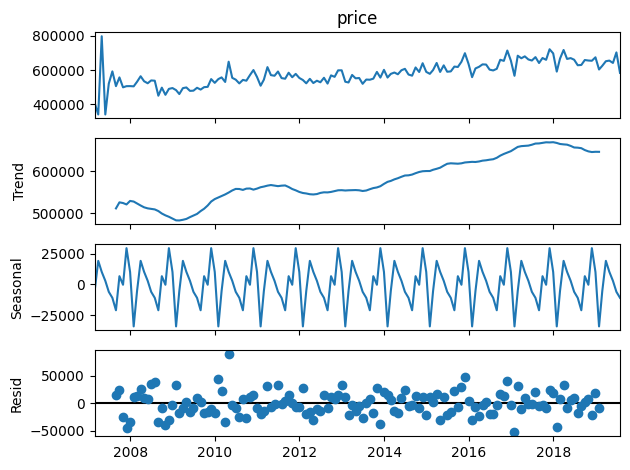

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly = monthly_df.loc['2007':'2019']

dec = seasonal_decompose(monthly['price'], model='additive', period=12)
dec.plot()
plt.show()

#### ADF & KPSS

In [19]:
from statsmodels.tsa.stattools import adfuller, kpss

series = monthly_df['price']

result = adfuller(series)

adf_result = adfuller(series)
print("ADF Test:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")


kpss_result = kpss(series, regression='c', nlags="auto")
print("\nKPSS Test:")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value: {kpss_result[1]:.4f}")
for key, value in kpss_result[3].items():
    print(f"Critical Value ({key}): {value:.4f}")

ADF Test:
ADF Statistic: -0.6602
p-value: 0.8568
Critical Value (1%): -3.4794
Critical Value (5%): -2.8830
Critical Value (10%): -2.5782

KPSS Test:
KPSS Statistic: 1.5950
p-value: 0.0100
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390


/tmp/ipykernel_19/1890852350.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags="auto")


##### ADF
- Null hypothesis (H₀): The series is non-stationary
- Alternative (H₁): The series is stationary
- Since p-value = 0.8568 > 0.05,
you fail to reject the null hypothesis,
so the series is non-stationary according to ADF.

##### KPSS
- Null hypothesis (H₀): The series is stationary
- Alternative (H₁): The series is non-stationary
- Since p-value = 0.0100 < 0.05,
you reject the null hypothesis,
so KPSS also says the series is non-stationary.

ADF: Non-stationary, KPSS: Non-stationary

So, your monthly property price series is non-stationary — it likely has trend and/or seasonality.

#### ADF KPSS functions

In [20]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, title='ADF Test'):
    """Perform Augmented Dickey-Fuller Test"""
    print(f"\n{title}")
    result = adfuller(series)
    labels = ['ADF Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
    for value, label in zip(result[0:4], labels):
        print(f"{label} : {value:.4f}")
    for key, val in result[4].items():
        print(f"Critical Value ({key}) : {val:.4f}")
    if result[1] <= 0.05:
        print("✅ Series is likely **stationary** (reject H0)")
    else:
        print("⚠️ Series is likely **non-stationary** (fail to reject H0)")

def kpss_test(series, title='KPSS Test'):
    """Perform KPSS Test"""
    print(f"\n{title}")
    result = kpss(series, regression='c', nlags='auto')
    labels = ['KPSS Statistic', 'p-value', '# Lags Used']
    for value, label in zip(result[0:3], labels):
        print(f"{label} : {value:.4f}")
    for key, val in result[3].items():
        print(f"Critical Value ({key}) : {val:.4f}")
    if result[1] <= 0.05:
        print("⚠️ Series is likely **non-stationary** (reject H0)")
    else:
        print("✅ Series is likely **stationary** (fail to reject H0)")


#### Differencing

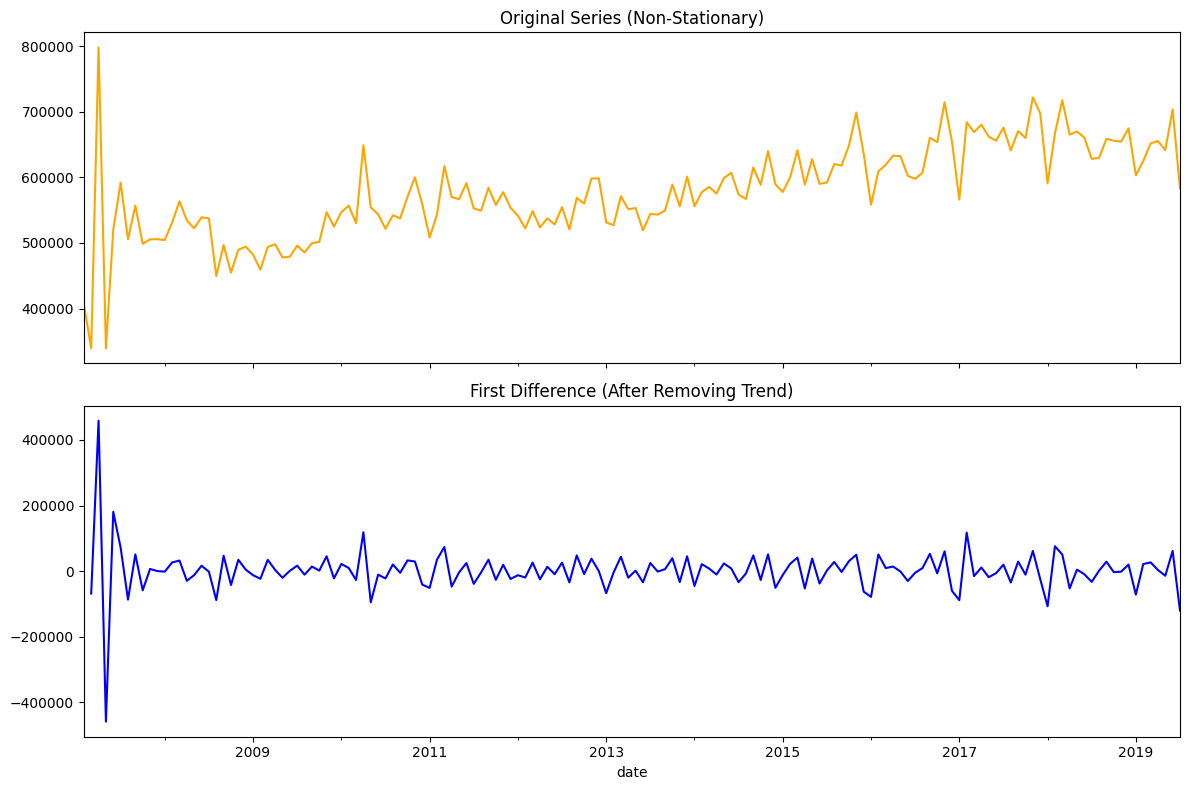

In [21]:
diff = series.diff()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

series.plot(ax=ax[0], title='Original Series (Non-Stationary)', color='orange')
diff.plot(ax=ax[1], title='First Difference (After Removing Trend)', color='blue')

plt.tight_layout()
plt.show()

In [22]:
diff = diff.dropna()

In [23]:
adf_test(diff)
kpss_test(diff)


ADF Test
ADF Statistic : -5.3038
p-value : 0.0000
# Lags Used : 10.0000
Number of Observations Used : 138.0000
Critical Value (1%) : -3.4786
Critical Value (5%) : -2.8827
Critical Value (10%) : -2.5781
✅ Series is likely **stationary** (reject H0)

KPSS Test
KPSS Statistic : 0.1069
p-value : 0.1000
# Lags Used : 8.0000
Critical Value (10%) : 0.3470
Critical Value (5%) : 0.4630
Critical Value (2.5%) : 0.5740
Critical Value (1%) : 0.7390
✅ Series is likely **stationary** (fail to reject H0)


/tmp/ipykernel_19/2007926552.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')


#### Plot ACF & PACF

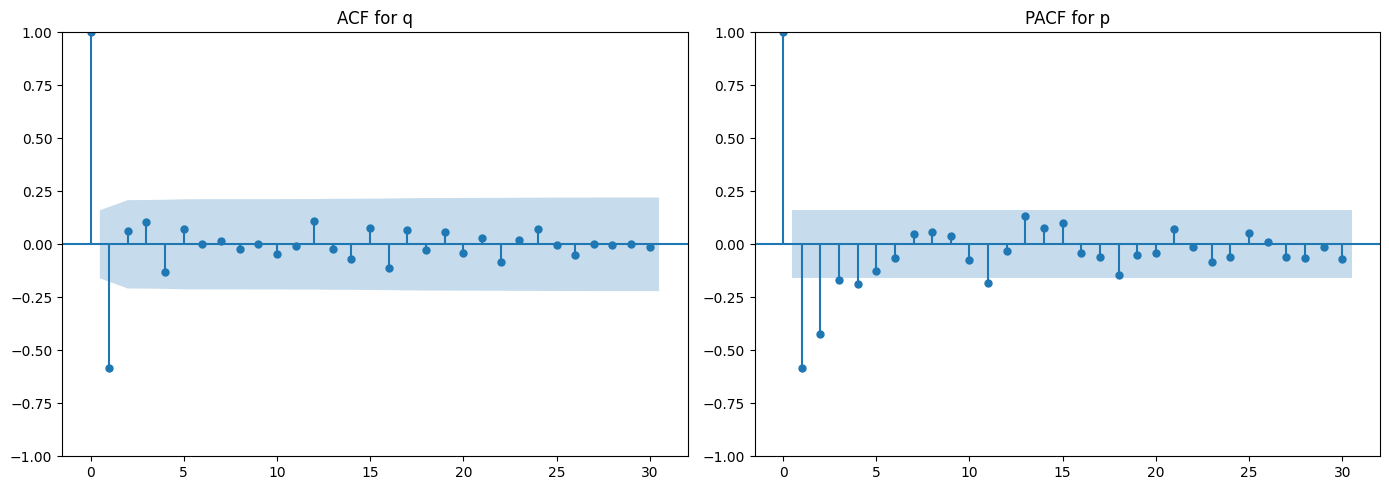

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig,axes = plt.subplots(1,2, figsize=(14,5))

plot_acf(diff, lags=30, ax=axes[0])
axes[0].set_title('ACF for q')

plot_pacf(diff, lags=30, ax=axes[1])
axes[1].set_title('PACF for p')

plt.tight_layout()
plt.show()

- ACF: cuts off after lag 2  → suggests an MA component, likely q ≈ 2.
- PACF: cuts off after lag 3  → suggests an AR component, likely p ≈ 3.

#### AIC/BIC

- The model with the lowest AIC/BIC gives the best tradeoff between accuracy and simplicity.

- Generally, AIC favors fit, BIC favors parsimony (fewer parameters).

#### Grid Search for pdq using AIC & BIC

In [25]:
series = monthly_df['price'].dropna()

In [26]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

p = range(0,4)
d = [1]
q = range(0,4)

pdq = list(itertools.product(p, d, q))

best_aic = float('inf')
best_bic = float('inf')
best_order_aic = None
best_order_bic = None

results_list = []

candidates = [(3,1,2), (2,1,2), (3,1,1), (1,1,1), (2,1,1), (1,1,2)]

for param in pdq:
    model = ARIMA(series, order=param)
    results = model.fit()

    results_list.append((param, results.aic, results.bic))
    
    if results.aic < best_aic:
        best_aic = results.aic
        best_order_aic = param
    if results.bic < best_bic:
        best_bic = results.bic
        best_order_bic = param

print(f"Best AIC: {best_aic:.2f} with order {best_order_aic}")
print(f"Best BIC: {best_bic:.2f} with order {best_order_bic}")

results_df = pd.DataFrame(results_list, columns=['(p,d,q)', 'AIC', 'BIC'])
print("\nSorted by AIC:")
print(results_df.sort_values(by='AIC').head(10))

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best AIC: 3686.24 with order (1, 1, 0)
Best BIC: 3692.25 with order (1, 1, 0)

Sorted by AIC:
      (p,d,q)          AIC          BIC
4   (1, 1, 0)  3686.237341  3692.245233
0   (0, 1, 0)  3741.586301  3744.590247
15  (3, 1, 3)  3751.752023  3772.779647
8   (2, 1, 0)  3759.780857  3768.792696
13  (3, 1, 1)  3769.459149  3784.478881
12  (3, 1, 0)  3772.604177  3784.619962
5   (1, 1, 1)  3778.878892  3787.890731
14  (3, 1, 2)  3781.617485  3799.641163
9   (2, 1, 1)  3784.180272  3796.196057
1   (0, 1, 1)  3784.774314  3790.782207


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Lowest AIC & BIC = ARIMA(1,1,0) ✅
- So this model has the best statistical balance of simplicity and fit.

- Your ACF/PACF suggested → ARIMA(3,1,2),
- but that has AIC = 3781.81, much higher (≈ +95 difference).

- AIC differences larger than ~10 are statistically significant, meaning (3,1,2) is clearly a worse fit here.

## ARIMA

In [27]:
from statsmodels.tsa.arima.model import ARIMA

In [28]:
model = ARIMA(train, order=(1,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  120
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1476.344
Date:                Sat, 01 Nov 2025   AIC                           2956.688
Time:                        14:20:20   BIC                           2962.246
Sample:                    02-28-2007   HQIC                          2958.945
                         - 01-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5143      0.026    -19.896      0.000      -0.565      -0.464
sigma2      3.304e+09   1.91e-12   1.73e+21      0.000     3.3e+09     3.3e+09
Ljung-Box (L1) (Q):                   1.05   Jarque-

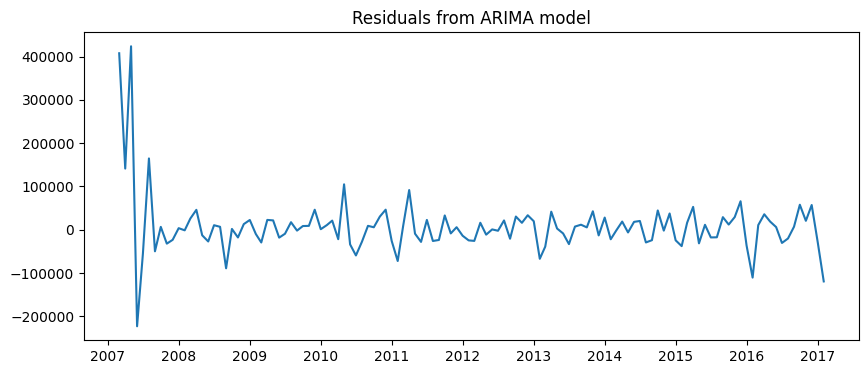

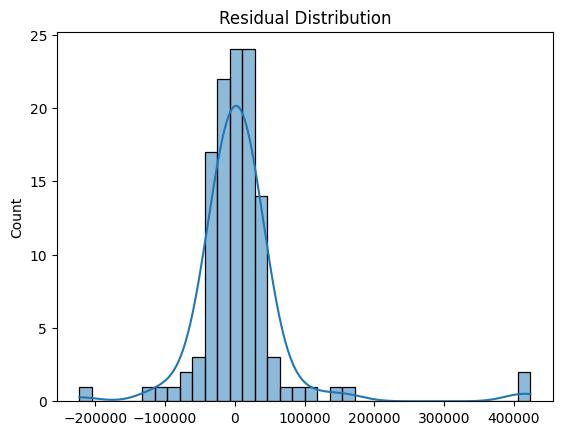

In [29]:
residuals = model_fit.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title('Residuals from ARIMA model')
plt.show()

sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

- What’s left (residuals) is just random noise.
- Model residuals are unbiased and constant variance.

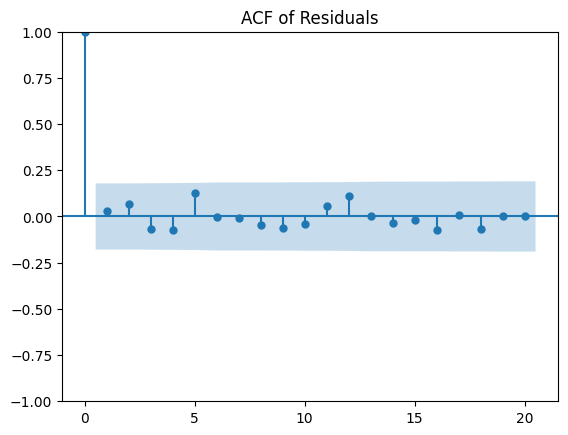

In [30]:
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

- This means there’s slight autocorrelation at lag 1, but it’s not very strong.= -
- Your model (ARIMA) has captured most of the time dependence

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

arima_forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test['price'], arima_forecast))
mae = mean_absolute_error(test['price'], arima_forecast)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 69375.22
MAE: 63067.00


In [32]:
avg_price = monthly_df['price'].mean()
print(f"Average Price Level: {avg_price:.2f}")

Average Price Level: 578152.13


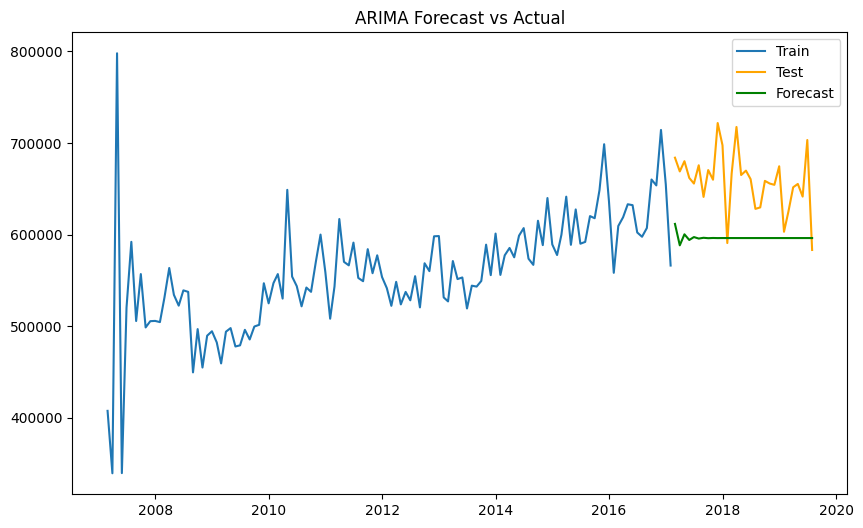

In [33]:
plt.figure(figsize=(10,6))
plt.plot(train.index, train['price'], label='Train')
plt.plot(test.index, test['price'], label='Test', color='orange')
plt.plot(test.index, arima_forecast, label='Forecast', color='green')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

For property data, which often has trend and mild seasonality, plain ARIMA (without seasonal terms) often performs like this.

## SARIMA

Since our data is monthly, Yearly pattern (season repeats every 12 months)

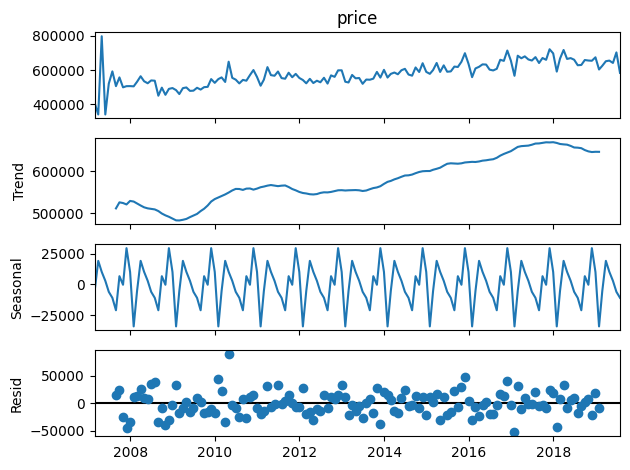

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_df['price'], model='additive', period=12)
decomposition.plot()
plt.show()

In [35]:
seasonally_diff = monthly_df['price'].diff(12).dropna()

from statsmodels.tsa.stattools import adfuller, kpss

print("ADF Test after seasonal differencing:")
print(adfuller(seasonally_diff)[1])

print("KPSS Test after seasonal differencing:")
print(kpss(seasonally_diff, regression='c', nlags="auto")[1])

ADF Test after seasonal differencing:
0.00102840078276505
KPSS Test after seasonal differencing:
0.1


/tmp/ipykernel_19/2800962323.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(kpss(seasonally_diff, regression='c', nlags="auto")[1])


Since both show stationarity now → D = 1 is appropriate.

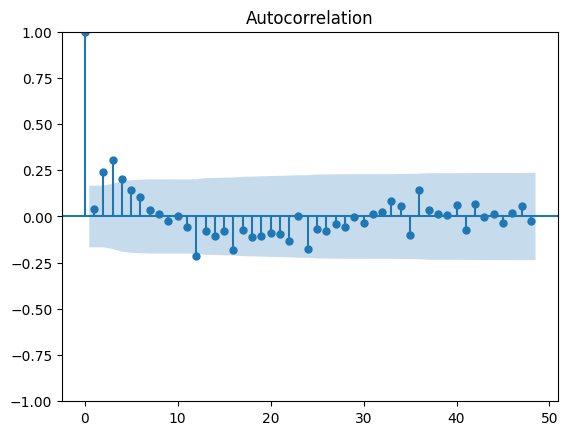

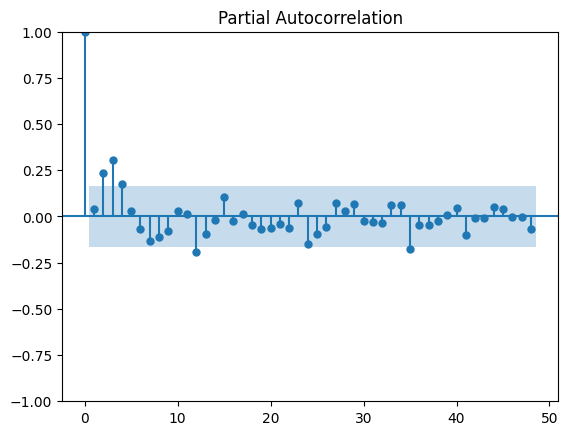

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(seasonally_diff, lags=48)
plot_pacf(seasonally_diff, lags=48)
plt.show()

SARIMA(1, 1, 0) x (1, 1, 1, 12)

In [37]:
# grid search

from statsmodels.tsa.statespace.sarimax import SARIMAX

d = D = [1]
p = q = (0,3)
P = Q = (0,2)
m = 12

pdq = list(itertools.product(p,d,q))
seasonal_pdq = list(itertools.product(P,D,Q,[m]))

results = []

for param in pdq:
    for sparam in seasonal_pdq:
        model = SARIMAX(monthly_df['price'],
                       order = param,
                       seasonal_order=sparam,
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        res = model.fit(disp=False)
        results.append({
            'order':param,
            'seasonal order':sparam,
            'AIC':res.aic,
            'BIC':res.bic
        })

result_df = pd.DataFrame(results)
print(result_df.sort_values(by='BIC').head(10))
print(result_df.sort_values(by='AIC').head(10))

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


        order seasonal order          AIC          BIC
5   (0, 1, 3)  (0, 1, 2, 12)  2571.957051  2588.105138
7   (0, 1, 3)  (2, 1, 2, 12)  2571.953356  2593.484139
13  (3, 1, 3)  (0, 1, 2, 12)  2571.322148  2595.544279
15  (3, 1, 3)  (2, 1, 2, 12)  2570.338847  2599.943674
10  (3, 1, 0)  (2, 1, 0, 12)  2596.494978  2612.697860
11  (3, 1, 0)  (2, 1, 2, 12)  2600.100757  2621.704600
14  (3, 1, 3)  (2, 1, 0, 12)  2599.122891  2623.427214
9   (3, 1, 0)  (0, 1, 2, 12)  2644.779666  2661.090659
6   (0, 1, 3)  (2, 1, 0, 12)  2665.244707  2681.609034
1   (0, 1, 0)  (0, 1, 2, 12)  2690.159128  2698.314625
        order seasonal order          AIC          BIC
15  (3, 1, 3)  (2, 1, 2, 12)  2570.338847  2599.943674
13  (3, 1, 3)  (0, 1, 2, 12)  2571.322148  2595.544279
7   (0, 1, 3)  (2, 1, 2, 12)  2571.953356  2593.484139
5   (0, 1, 3)  (0, 1, 2, 12)  2571.957051  2588.105138
10  (3, 1, 0)  (2, 1, 0, 12)  2596.494978  2612.697860
14  (3, 1, 3)  (2, 1, 0, 12)  2599.122891  2623.427214
11  (3, 1,

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                                price   No. Observations:                  120
Model:             SARIMAX(1, 1, 0)x(1, 1, [1], 12)   Log Likelihood               -1136.361
Date:                              Sat, 01 Nov 2025   AIC                           2280.722
Time:                                      14:20:33   BIC                           2290.895
Sample:                                  02-28-2007   HQIC                          2284.831
                                       - 01-31-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5417      0.272     -1.993      0.046      -1.075      -0.009
ar.S.L12       0.10

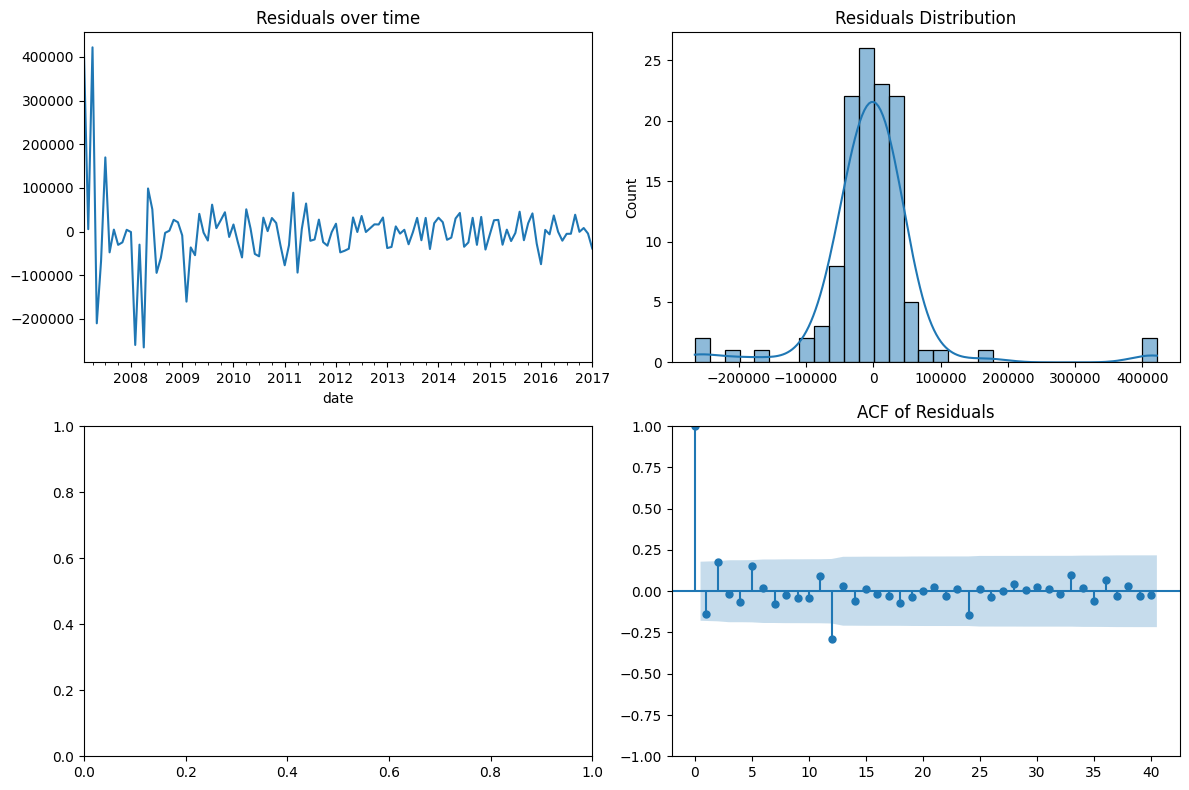

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['price'],
                order=(1, 1, 0),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
sarima_result = model.fit()
print(sarima_result.summary())

residuals = sarima_result.resid

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Residuals vs time
residuals.plot(ax=ax[0,0])
ax[0,0].set_title('Residuals over time')

# Histogram + KDE
sns.histplot(residuals, kde=True, ax=ax[0,1])
ax[0,1].set_title('Residuals Distribution')

# ACF plot of residuals
plot_acf(residuals, ax=ax[1,1], lags=40)
ax[1,1].set_title('ACF of Residuals')

plt.tight_layout()
plt.show()

forecast_steps = len(test)
sarima_forecast = sarima_result.forecast(steps=forecast_steps)


Forecast Accuracy:
MAE = 28740.88
RMSE = 36464.43


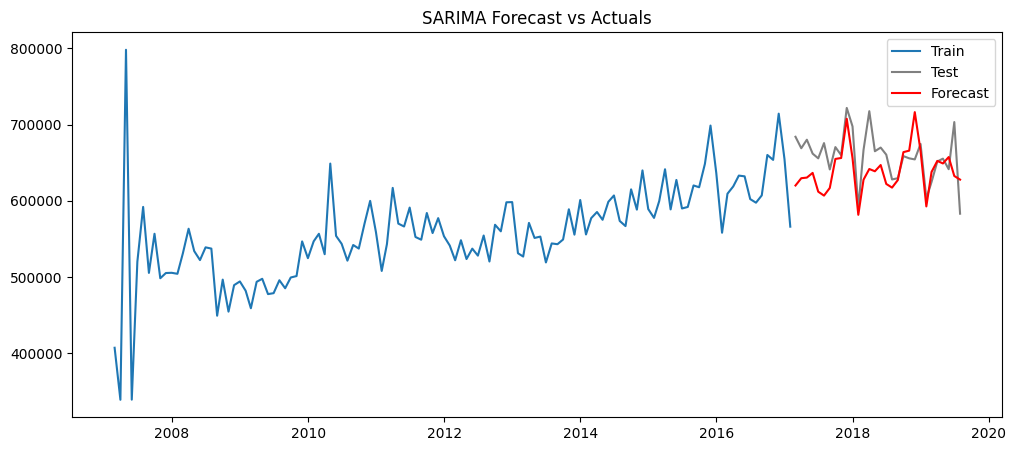

In [39]:
# Evaluate accuracy
mae = mean_absolute_error(test['price'], sarima_forecast)
rmse = np.sqrt(mean_squared_error(test['price'], sarima_forecast))
print(f"\nForecast Accuracy:")
print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")

plt.figure(figsize=(12,5))
plt.plot(train.index, train['price'], label='Train')
plt.plot(test.index, test['price'], label='Test', color='gray')
plt.plot(test.index, sarima_forecast, label='Forecast', color='red')
plt.title('SARIMA Forecast vs Actuals')
plt.legend()
plt.show()

- The model performs significantly better than your earlier ARIMA model (which had RMSE ≈ 69,000).
- This improvement indicates that seasonal components (m=12) were indeed important.
- Residual diagnostics likely show mostly white noise, meaning the model has captured most of the structure.

## Holt-Winters / Exponential Smoothing

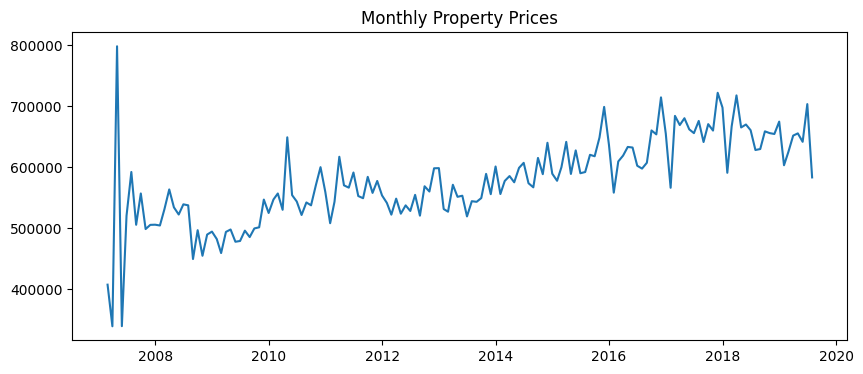

In [40]:
plt.figure(figsize=(10,4))
plt.plot(monthly_df['price'])
plt.title("Monthly Property Prices")
plt.show()

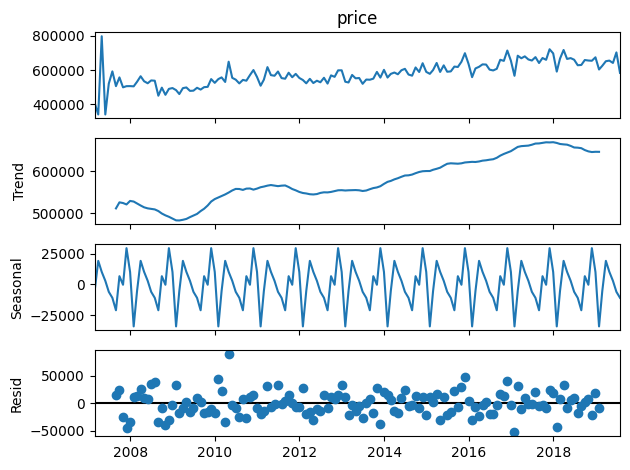

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(monthly_df['price'],model='additive', period=12)
result.plot()
plt.show()

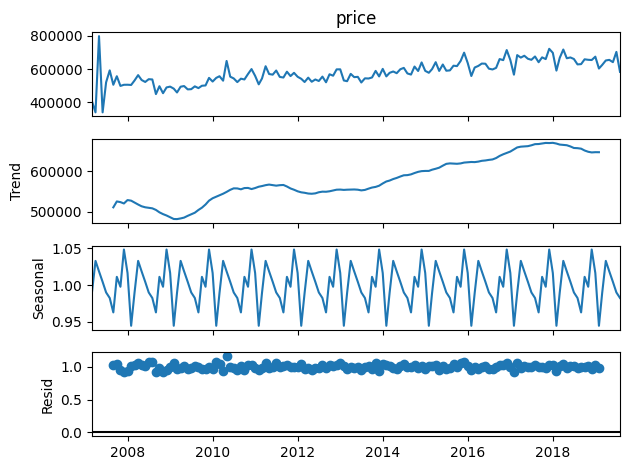

In [42]:
result = seasonal_decompose(monthly_df['price'],model='multiplicative', period=12)
result.plot()
plt.show()

In the additive model, the decomposition is struggling to fit the changing variance (the seasonal fluctuations grow with the level), leading to more random leftover noise.

In the multiplicative model, the seasonal and trend components explain the data more effectively, leaving behind smaller, more consistent residuals.
- So the multiplicative model fits your series better.

In [43]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train['price'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit(optimized=True)

In [44]:
print("Alpha:", hw_model.params['smoothing_level'])
print("Beta:", hw_model.params['smoothing_trend'])
print("Gamma:", hw_model.params['smoothing_seasonal'])

Alpha: 0.1221794630988048
Beta: 0.024011549070965865
Gamma: 0.0


In [45]:
pred_hw = hw_model.forecast(len(test))

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['price'], pred_hw)
rmse = np.sqrt(mean_squared_error(test['price'], pred_hw))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 29163.23
RMSE: 35255.13


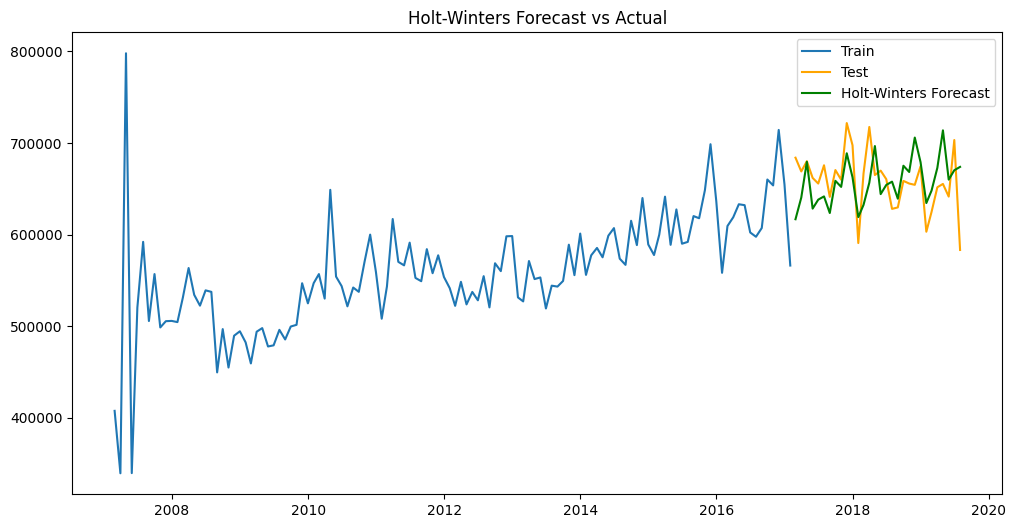

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train.index, train['price'], label='Train')
plt.plot(test.index, test['price'], label='Test', color='orange')
plt.plot(test.index, pred_hw, label='Holt-Winters Forecast', color='green')
plt.title('Holt-Winters Forecast vs Actual')
plt.legend()
plt.show()

Holt-Winters showed a slight improvement in **RMSE**, indicating it captured the **seasonal fluctuations** more smoothly than SARIMA.


## Prophet

In [47]:
prophet_df = monthly_df.reset_index()[['date','price']]
prophet_df = prophet_df.rename(columns={'date':'ds', 'price':'y'})

In [48]:
train = prophet_df.iloc[:-30]
test  = prophet_df.iloc[-30:]

In [49]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

model.fit(train)

14:20:38 - cmdstanpy - INFO - Chain [1] start processing
14:20:38 - cmdstanpy - INFO - Chain [1] done processing


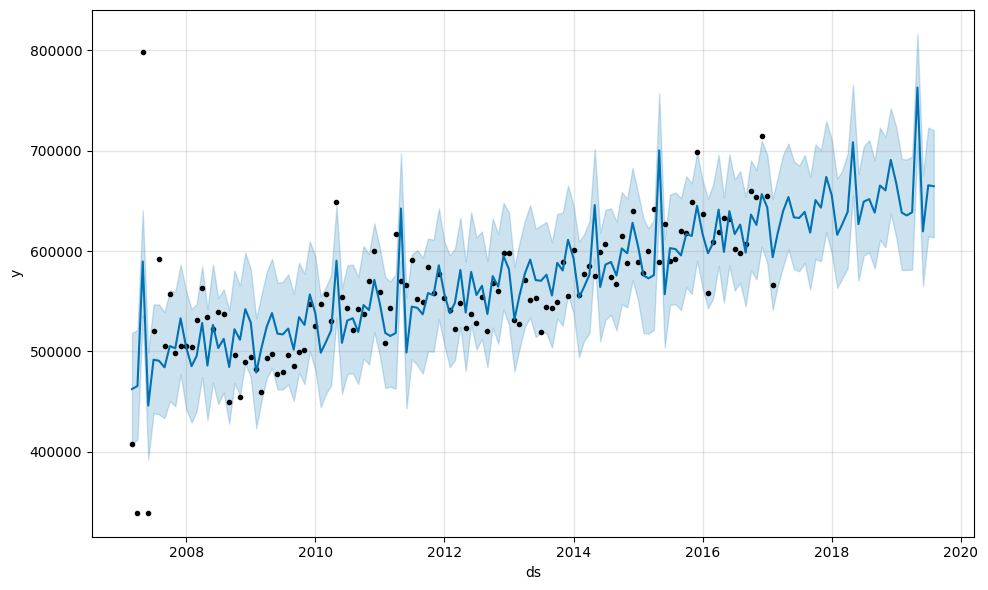

In [50]:
future = model.make_future_dataframe(periods=len(test), freq='M')

forecast = model.predict(future)

model.plot(forecast)
plt.show()

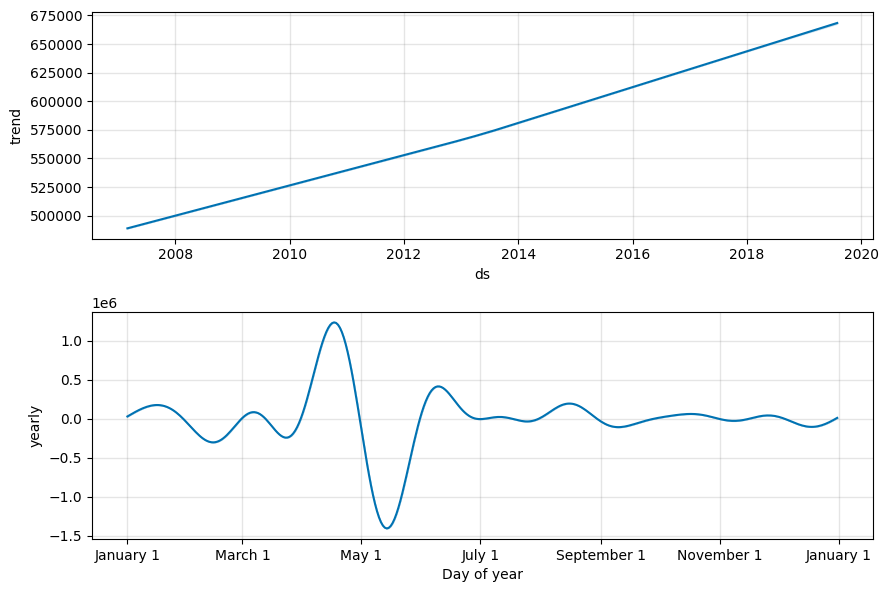

In [51]:
model.plot_components(forecast)
plt.show()

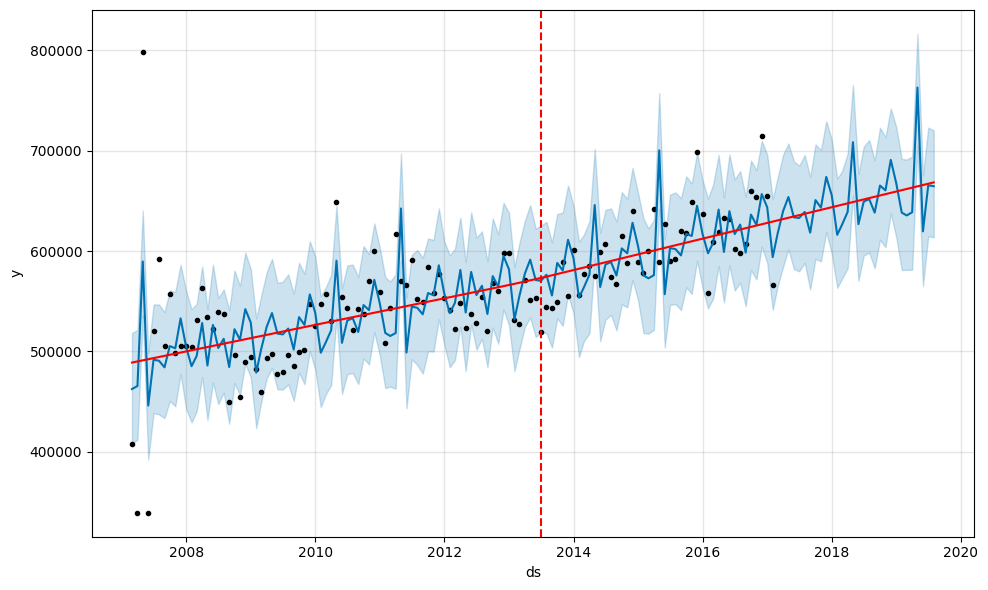

In [52]:
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

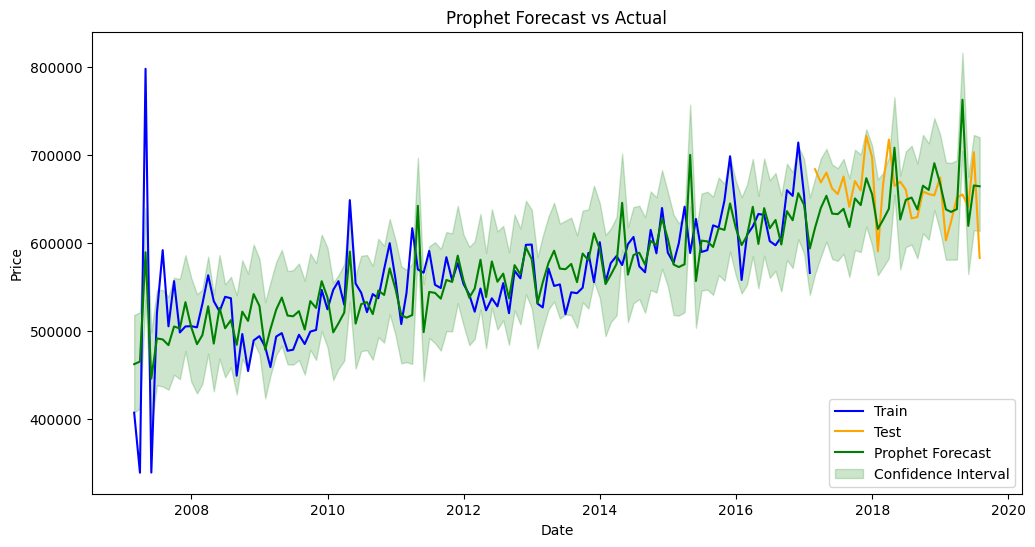

In [53]:
plt.figure(figsize=(12,6))
plt.plot(train['ds'], train['y'], label='Train', color='blue')
plt.plot(test['ds'], test['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='green')

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='green',
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Prophet does forecast both training and testing periods by design, and that’s actually useful for understanding how well it fits past data before trusting its future predictions.

In [54]:
y_true = test['y'].values
y_pred = forecast.tail(len(test))['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))


print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")

MAE = 33176.10
RMSE = 40772.59


#### Tuning flexibility and seasonality

In [55]:
results = []

for cps in [0.001, 0.01, 0.1, 0.5]:
    for sps in [1, 5, 10]:
        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps
        )
        model.fit(train)

        future = model.make_future_dataframe(periods=len(test), freq='M')
        forecast = model.predict(future)

        y_pred = forecast.tail(len(test))['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        results.append({
            'Changepoint Prior Scale': cps,
            'Seasonality Prior Scale': sps,
            'MAE': mae,
            'RMSE': rmse
        })

# Convert to DataFrame and sort by RMSE
prophet_results = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)

print(prophet_results)

14:20:40 - cmdstanpy - INFO - Chain [1] start processing
14:20:40 - cmdstanpy - INFO - Chain [1] done processing
14:20:40 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
14:20:40 - cmdstanpy - INFO - Chain [1] start processing
14:20:40 - cmdstanpy - INFO - Chain [1] done processing
14:20:40 - cmdstanpy - INFO - Chain [1] start processing
14:20:40 - cmdstanpy - INFO - Chain [1] done processing
14:20:40 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
14:20:40 - cmdstanpy - INFO - Chain [1] start processing
14:20:41 - cmdstanpy - INFO - Chain [1] done processing
14:20:41 - cmdstanpy - INFO - Chain [1] start processing
14:20:41 - cmdstanpy - INFO - Chain [1] done processing
14:20:41 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
14:20:41 - cmdstanpy - INFO - Chain [1] start processing
14:20:41 - cmdstanpy - INFO - Chain [1] done processing
14:20:41 - cmdstanpy - INFO - Chai

    Changepoint Prior Scale  Seasonality Prior Scale           MAE  \
0                     0.010                       10  29270.851940   
1                     0.010                        5  29310.013912   
2                     0.010                        1  29895.732725   
3                     0.100                        1  31265.103828   
4                     0.100                       10  31192.155916   
5                     0.100                        5  31214.975024   
6                     0.001                        5  33229.147053   
7                     0.001                       10  34377.741554   
8                     0.001                        1  34652.335348   
9                     0.500                       10  33072.629527   
10                    0.500                        1  33195.918755   
11                    0.500                        5  33286.290885   

            RMSE  
0   35374.069378  
1   35376.245930  
2   36428.016833  
3   39923.066

In [56]:
model = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.010,
    seasonality_prior_scale=5
)

model.fit(train)
forecast = model.predict(future)

14:20:42 - cmdstanpy - INFO - Chain [1] start processing
14:20:42 - cmdstanpy - INFO - Chain [1] done processing


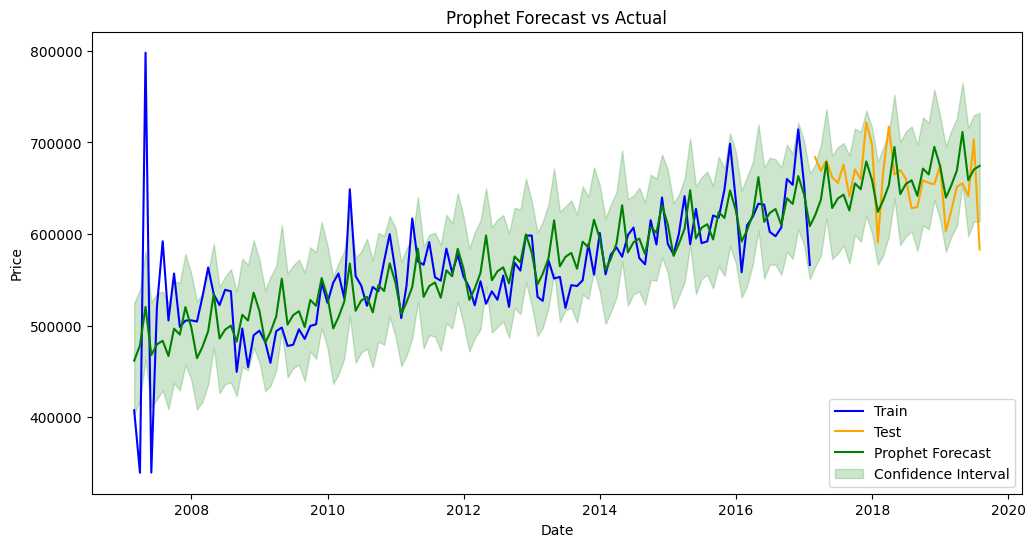

In [57]:
plt.figure(figsize=(12,6))
plt.plot(train['ds'], train['y'], label='Train', color='blue')
plt.plot(test['ds'], test['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='green')

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='green',
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [58]:
y_true = test['y'].values
y_pred = forecast.tail(len(test))['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))


print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")

MAE = 29310.01
RMSE = 35376.25


## LSTM

In [59]:
train = monthly_df.iloc[:-30]
test  = monthly_df.iloc[-30:]

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

#fitting only on train data to avoid data leakage
train_scaled = scaler.fit_transform(train[['price']])
test_scaled = scaler.transform(test[['price']])

In [61]:
# creating sequence

def create_sequence(data, seq_length=12):
    X,y = [],[]
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X_train, y_train = create_sequence(train_scaled, seq_length)
X_test, y_test = create_sequence(test_scaled, seq_length)

In [62]:
# reshaping

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1],1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1],1))

In [63]:
# LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='relu', return_sequences=False, input_shape=(X_train.shape[1],1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

2025-11-01 14:20:45.230285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762006845.423636      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762006845.481312      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1762006857.705902      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# early stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [65]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


I0000 00:00:1762006861.343704      78 service.cc:148] XLA service 0x79bc84052900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762006861.344204      78 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762006861.651727      78 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - loss: 0.2379

I0000 00:00:1762006862.405972      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - loss: 0.1932 - val_loss: 0.1736
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0640 - val_loss: 0.0128
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0081 - val_loss: 0.0063
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - val_loss: 0.0082
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - val_loss: 0.0049
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0068 - val_loss: 0.0053
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0054
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0053
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0063 - val_loss: 0.0048
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - val_

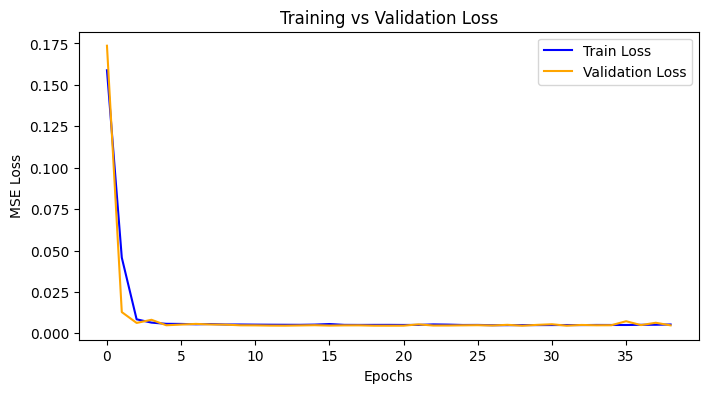

In [66]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

If validation loss starts increasing while training loss keeps decreasing, that’s overfitting.

You can counter this by:

Reducing model complexity (fewer LSTM units/layers)

Adding Dropout

Increasing patience or reducing epochs

In [67]:
y_pred_scaled = model.predict(X_test)

y_pred_lstm = scaler.inverse_transform(y_pred_scaled)
y_true_lstm = scaler.inverse_transform(y_test.reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step


In [68]:
mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))

print(f"LSTM : MAE={mae:.2f}, RMSE={rmse:.2f}")

LSTM : MAE=29310.01, RMSE=35376.25


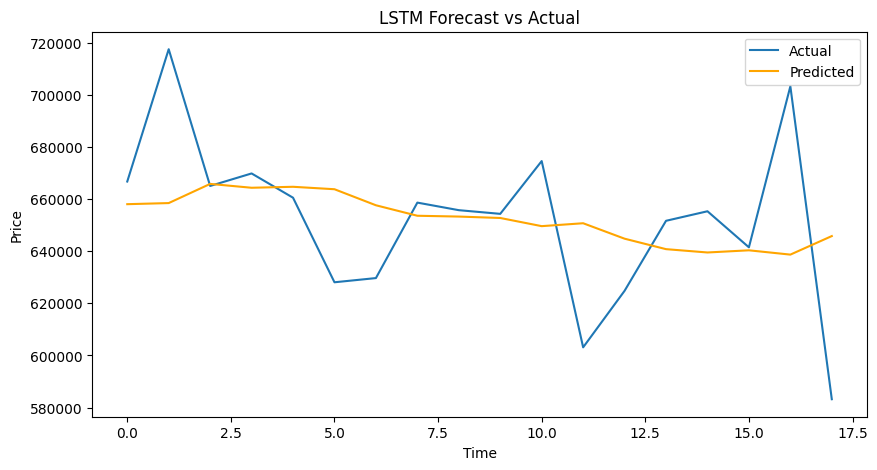

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_true_lstm, label='Actual')
plt.plot(y_pred_lstm, label='Predicted', color='orange')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

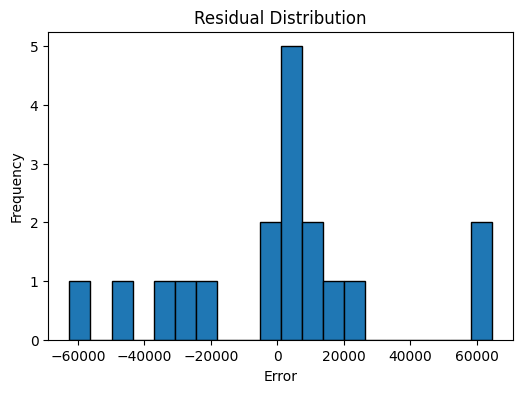

In [70]:
residuals = y_true_lstm - y_pred_lstm

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20, edgecolor='k')
plt.title('Residual Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()


## Comparison

In [71]:
y_true = test['price']

In [72]:
models = {
    'ARIMA': arima_forecast,
    'SARIMA': sarima_forecast,
    'Holt-Winters': pred_hw,
    'Prophet': y_pred
}

comparison = []

for name, y_hat in models.items():
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    comparison.append({'Model': name, 'MAE': mae, 'RMSE': rmse})

comparison.append({'Model': 'LSTM', 'MAE': mae_lstm, 'RMSE': rmse_lstm})

results_df = pd.DataFrame(comparison).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
print(results_df)

          Model           MAE          RMSE
0          LSTM  22144.267044  31139.874202
1  Holt-Winters  29163.232691  35255.131696
2       Prophet  29310.013912  35376.245930
3        SARIMA  28740.882533  36464.429812
4         ARIMA  63067.004840  69375.222280


Use time-series cross-validation (rolling origin) for more robust comparison.

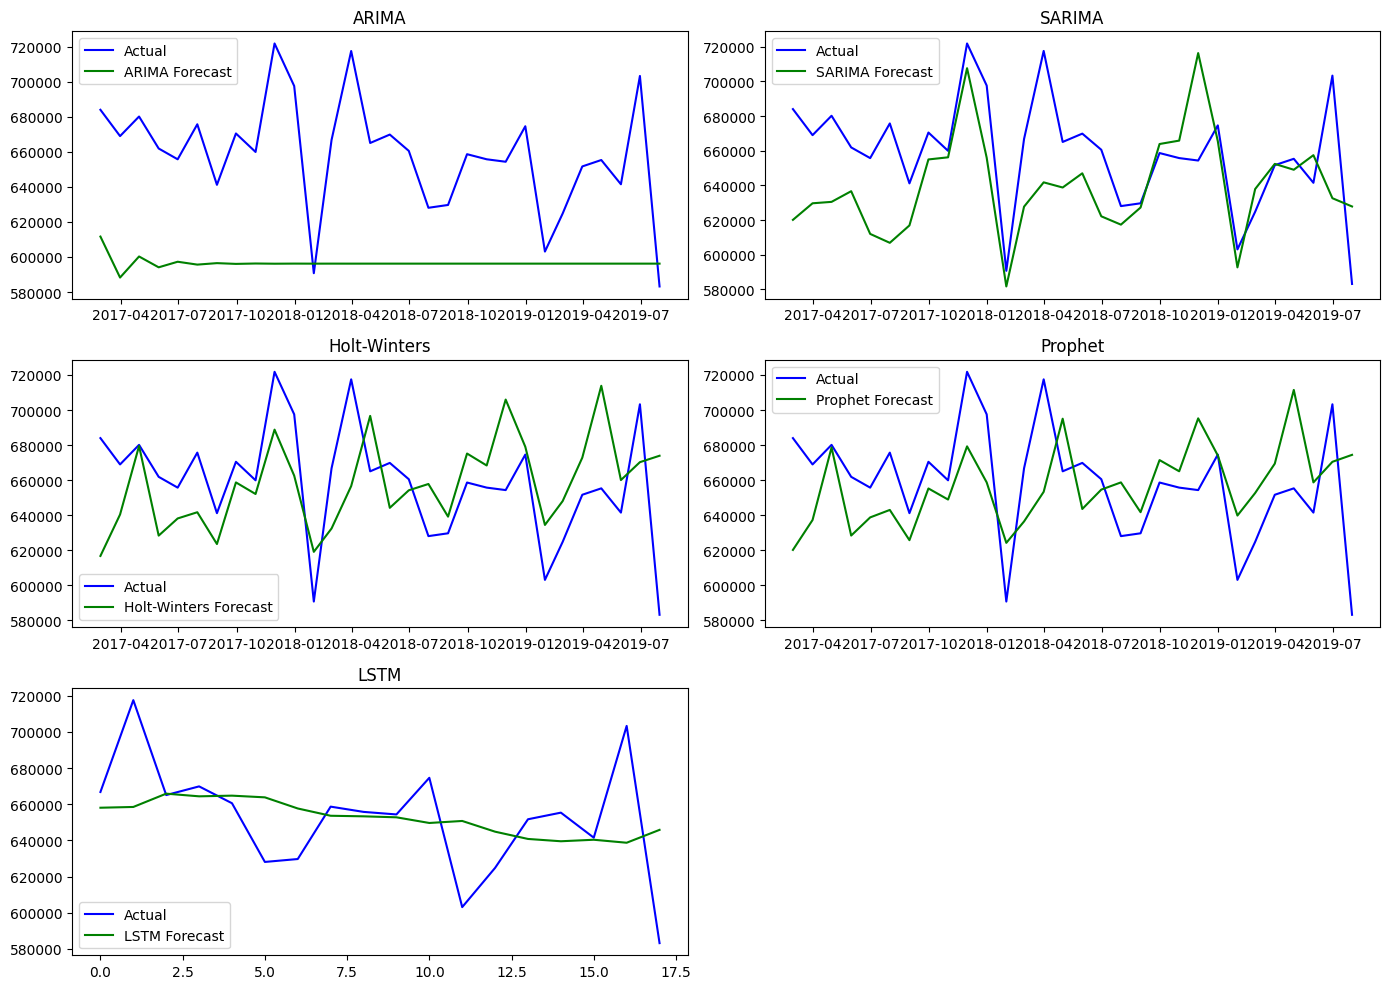

In [73]:
plt.figure(figsize=(14,10))

# ARIMA
plt.subplot(3,2,1)
plt.plot(test.index, test['price'], label='Actual', color='blue')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='green')
plt.title('ARIMA')
plt.legend()

# SARIMA
plt.subplot(3,2,2)
plt.plot(test.index, test['price'], label='Actual', color='blue')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='green')
plt.title('SARIMA')
plt.legend()

# Holt-Winters
plt.subplot(3,2,3)
plt.plot(test.index, test['price'], label='Actual', color='blue')
plt.plot(test.index, pred_hw, label='Holt-Winters Forecast', color='green')
plt.title('Holt-Winters')
plt.legend()

# Prophet
test_p  = prophet_df.iloc[-30:]
plt.subplot(3,2,4)
plt.plot(test_p['ds'], test_p['y'], label='Actual', color='blue')
plt.plot(test_p['ds'], y_pred, label='Prophet Forecast', color='green')
plt.title('Prophet')
plt.legend()

# LSTM
plt.subplot(3,2,5)
plt.plot( y_true_lstm, label='Actual', color='blue')
plt.plot( y_pred_lstm, label='LSTM Forecast', color='green')
plt.title('LSTM')
plt.legend()

plt.tight_layout()
plt.show()

## Final Insight

Deep learning approaches like LSTM outperform traditional statistical models in capturing non-linear and time-dependent variations in property prices. However, simpler models such as Holt-Winters and Prophet remain valuable for quick and interpretable forecasting where model transparency is important.